# CredResolve Collections Analytics - Forensic Investigation
This notebook reconstructs trustworthy collections performance, challenges the reported 11% MoM recovery claim, investigates drivers/biases, and evaluates the ₹10 Cr investment decision. **Evidence labels are used throughout: Fact / Strong Evidence / Correlation / Hypothesis.**

In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path
ROOT=Path('..')
golden=pd.read_csv(ROOT/'data/golden/golden_account_month.csv')
monthly=pd.read_csv(ROOT/'data/golden/monthly_metrics.csv')
kpi=pd.read_csv(ROOT/'data/golden/kpi_monthly.csv')
monthly

,month,valid_payments,recovery,payer_accounts,mom_recovery_pct,target_accounts,target_exposure,targeted_recovery,successful_payments,targeted_recovery_rate,mom_rate_pct
0,2026-01,2464,1.872291e+08,2374,NaN,5732,2.004730e+09,37196059.79,478.0,0.018554,NaN
1,2026-02,2268,1.701425e+08,2173,-9.126077,5160,1.803178e+09,27945637.33,371.0,0.015498,-16.471561
2,2026-03,2524,1.889124e+08,2419,11.031885,5666,1.970422e+09,38435405.07,493.0,0.019506,25.862595
3,2026-04,2406,1.751380e+08,2304,-7.291386,5585,1.944509e+09,33069350.75,448.0,0.017007,-12.814640
4,2026-05,2449,1.842503e+08,2344,5.202887,5800,2.029887e+09,34329594.37,466.0,0.016912,-0.555419
5,2026-06,2366,1.755597e+08,2286,-4.716710,5535,1.934677e+09,32859753.05,444.0,0.016985,0.428944
6,2026-07,2441,1.872423e+08,2335,6.654452,5666,2.036531e+09,37763870.63,501.0,0.018543,9.176628
7,2026-08,616,4.710970e+07,608,-74.840245,1566,5.460112e+08,1715710.57,24.0,0.003142,-83.054398


## 1. Data inventory and source-of-truth decisions
**Fact:** `account_id` is present and referentially valid across core event tables. Event-level `borrower_id` is contradictory to the account master in ~98% of event rows, therefore segmentation is derived via `accounts.borrower_id`, not event borrower IDs. Payment event identity is based on `payment_id`; `payment_reference` is not globally unique and cannot safely be used as a universal dedupe key.

In [2]:
dq=pd.read_csv(ROOT/'reports/data_quality_summary.csv'); dq.head(25)

,dataset,rows,exact_duplicate_rows,missing_cells_pct,issue
0,borrowers,30600,600.0,0.616,NaN
1,accounts,30000,0.0,0.138,NaN
2,agents,30000,0.0,0.000,NaN
3,agent_sessions,15000,0.0,0.000,NaN
4,campaigns,120,0.0,0.000,NaN
5,daily_targeting,45000,0.0,0.000,NaN
6,calls,91350,1271.0,0.182,NaN
7,call_attempts,120000,0.0,0.222,NaN
8,call_dispositions,35000,0.0,0.000,NaN
9,whatsapp_events,60600,600.0,0.000,NaN


## 2. Golden dataset
Grain: **targeted account × month**. This provides an auditable denominator and prevents repeat attempts/messages from inflating conversion denominators.

In [3]:
golden.head(); print(golden.shape); print(golden[['account_id','month']].duplicated().sum(), 'duplicate account-month rows')

(40710, 35)
0 duplicate account-month rows


## 3. Independent KPI definitions
Recovery = deduped `SUCCESS` payment amount. Targeted recovery rate = recovery from targeted accounts / outstanding exposure of unique targeted accounts. Contact = ANSWERED call / calls. RPC = right-party dispositions / dispositioned calls. PTP kept = KEPT / (KEPT + BROKEN) for promises due by data cutoff.

In [4]:
kpi[['month','recovery','targeted_recovery_rate','contact_rate','rpc_rate','ptp_rate','ptp_kept_rate','recovery_per_account','recovery_per_agent_hour']]

,month,recovery,targeted_recovery_rate,contact_rate,rpc_rate,ptp_rate,ptp_kept_rate,recovery_per_account,recovery_per_agent_hour
0,2026-01,1.872291e+08,0.018554,0.200505,0.800197,0.330873,0.485212,32663.839426,16772.928023
1,2026-02,1.701425e+08,0.015498,0.196992,0.803748,0.326116,0.507156,32973.343752,16116.535968
2,2026-03,1.889124e+08,0.019506,0.199844,0.801909,0.330655,0.495994,33341.400286,16972.008713
3,2026-04,1.751380e+08,0.017007,0.192974,0.808230,0.312382,0.500796,31358.646985,16490.841700
4,2026-05,1.842503e+08,0.016912,0.203358,0.813298,0.312204,0.493002,31767.289397,17008.038551
5,2026-06,1.755597e+08,0.016985,0.203991,0.804439,0.320351,0.494253,31718.107854,16402.838991
6,2026-07,1.872423e+08,0.018543,0.193433,0.797747,0.314402,0.506173,33046.640501,16747.728864
7,2026-08,4.710970e+07,0.003142,0.196262,0.812734,0.306452,0.588235,30082.819483,17552.964829


## 4. Is the reported +11% real?
**Fact:** Feb→Mar raw successful-payment recovery rises by ~11.0%. After payment-ID deduplication it still rises by ~11.03%, so duplicate rows do not explain the claim. **Strong Evidence:** on the targeted-exposure denominator, recovery rate rises by ~25.86%; standardizing March to the February DPD×risk×loan mix gives ~26.17%, so portfolio mix does not explain the spike. **However:** Jan-Jul recovery has no sustained linear trend; March is followed by a decline in April.

In [5]:
monthly[['month','recovery','mom_recovery_pct','targeted_recovery_rate','mom_rate_pct']]

,month,recovery,mom_recovery_pct,targeted_recovery_rate,mom_rate_pct
0,2026-01,1.872291e+08,NaN,0.018554,NaN
1,2026-02,1.701425e+08,-9.126077,0.015498,-16.471561
2,2026-03,1.889124e+08,11.031885,0.019506,25.862595
3,2026-04,1.751380e+08,-7.291386,0.017007,-12.814640
4,2026-05,1.842503e+08,5.202887,0.016912,-0.555419
5,2026-06,1.755597e+08,-4.716710,0.016985,0.428944
6,2026-07,1.872423e+08,6.654452,0.018543,9.176628
7,2026-08,4.710970e+07,-74.840245,0.003142,-83.054398


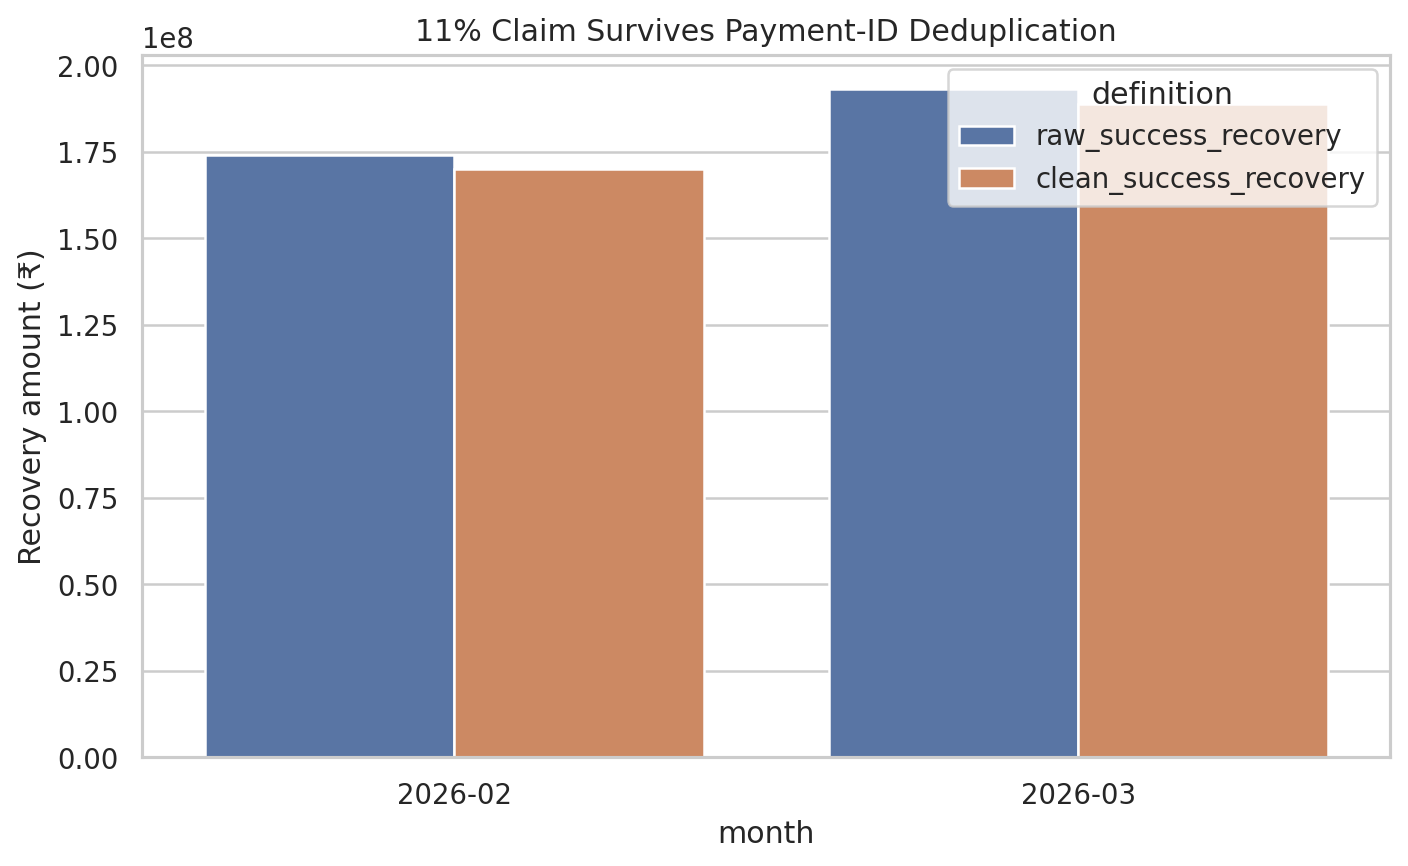

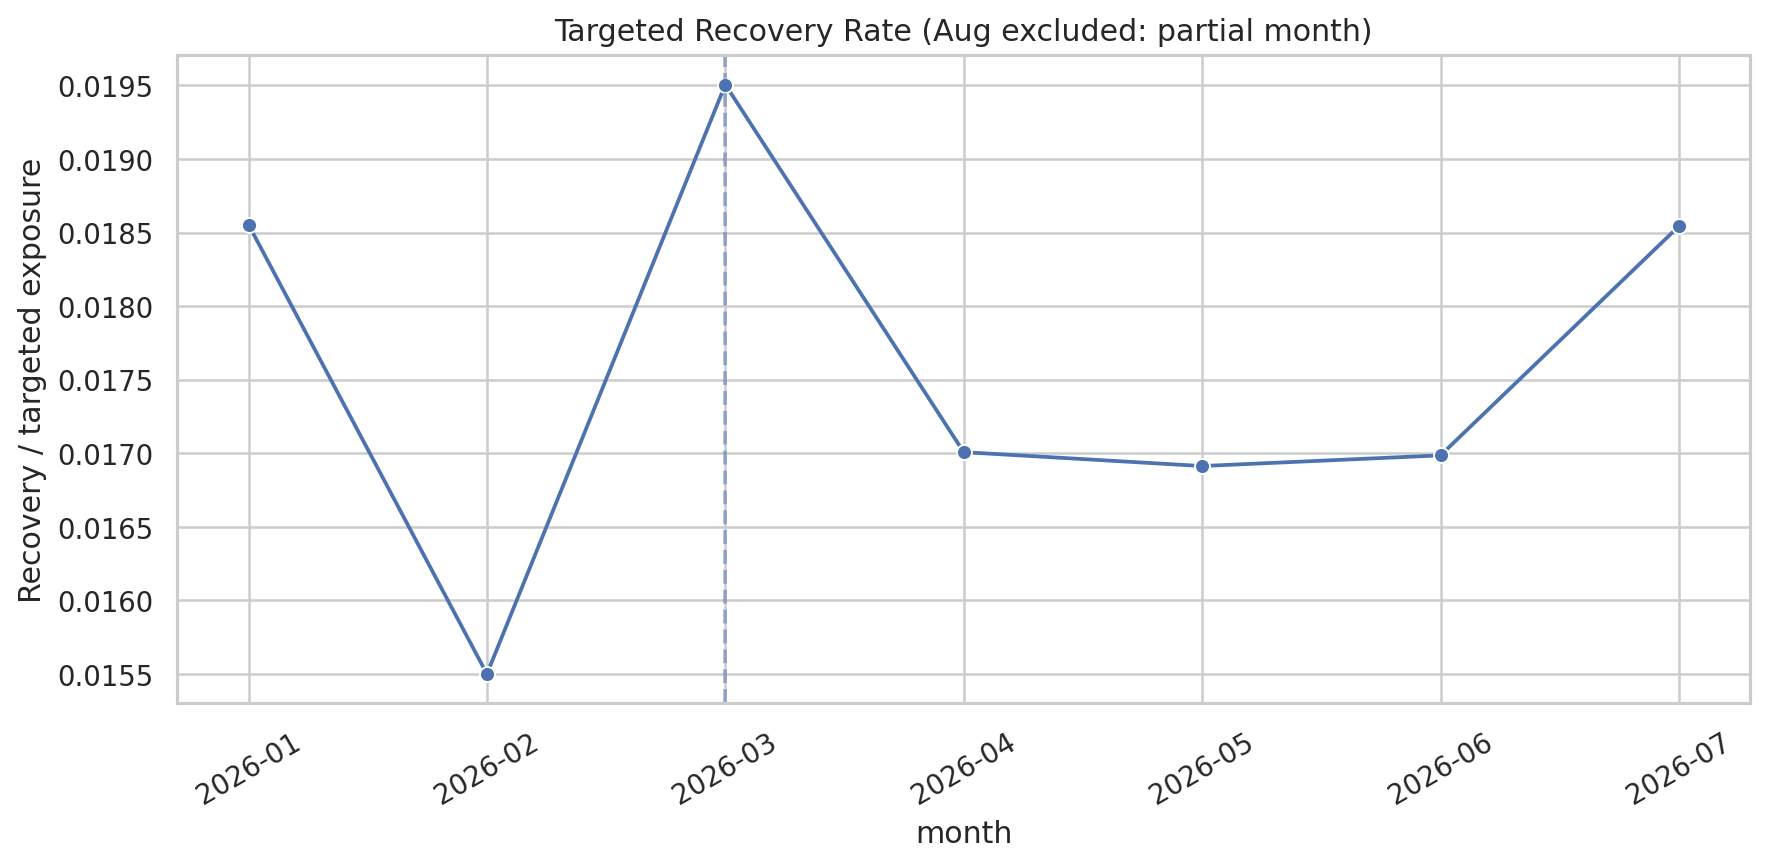

In [6]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'reports/charts/11_claim_reconciliation.png'))); display(Image(filename=str(ROOT/'reports/charts/02_targeted_recovery_rate.png')))

## 5. Data forensics
Major issues: duplicate payment/call/message events, conflicting borrower IDs, impossible master-record timestamp orderings, partial August, mixed time zones, and non-unique/unstable agent employee codes. These are treated as first-class findings rather than hidden cleaning steps.

In [7]:
pd.read_csv(ROOT/'data/golden/payment_reconciliation.csv').round(2)

,month,raw_success_recovery,clean_success_recovery,duplicate_inflation,cleaning_impact_pct
0,2026-01,1.911333e+08,1.872291e+08,3904156.83,2.04
1,2026-02,1.740973e+08,1.701425e+08,3954834.20,2.27
2,2026-03,1.932334e+08,1.889124e+08,4321010.27,2.24
3,2026-04,1.784270e+08,1.751380e+08,3288973.64,1.84
4,2026-05,1.870481e+08,1.842503e+08,2797865.84,1.50
5,2026-06,1.787245e+08,1.755597e+08,3164766.49,1.77
6,2026-07,1.902788e+08,1.872423e+08,3036581.80,1.60
7,2026-08,4.854347e+07,4.710970e+07,1433772.62,2.95


## 6. Driver investigation
The next views test DPD, risk, loan type, targeting priority, vendor, channel, calling time, and attempt frequency. These are **associations unless explicitly identified causally**.

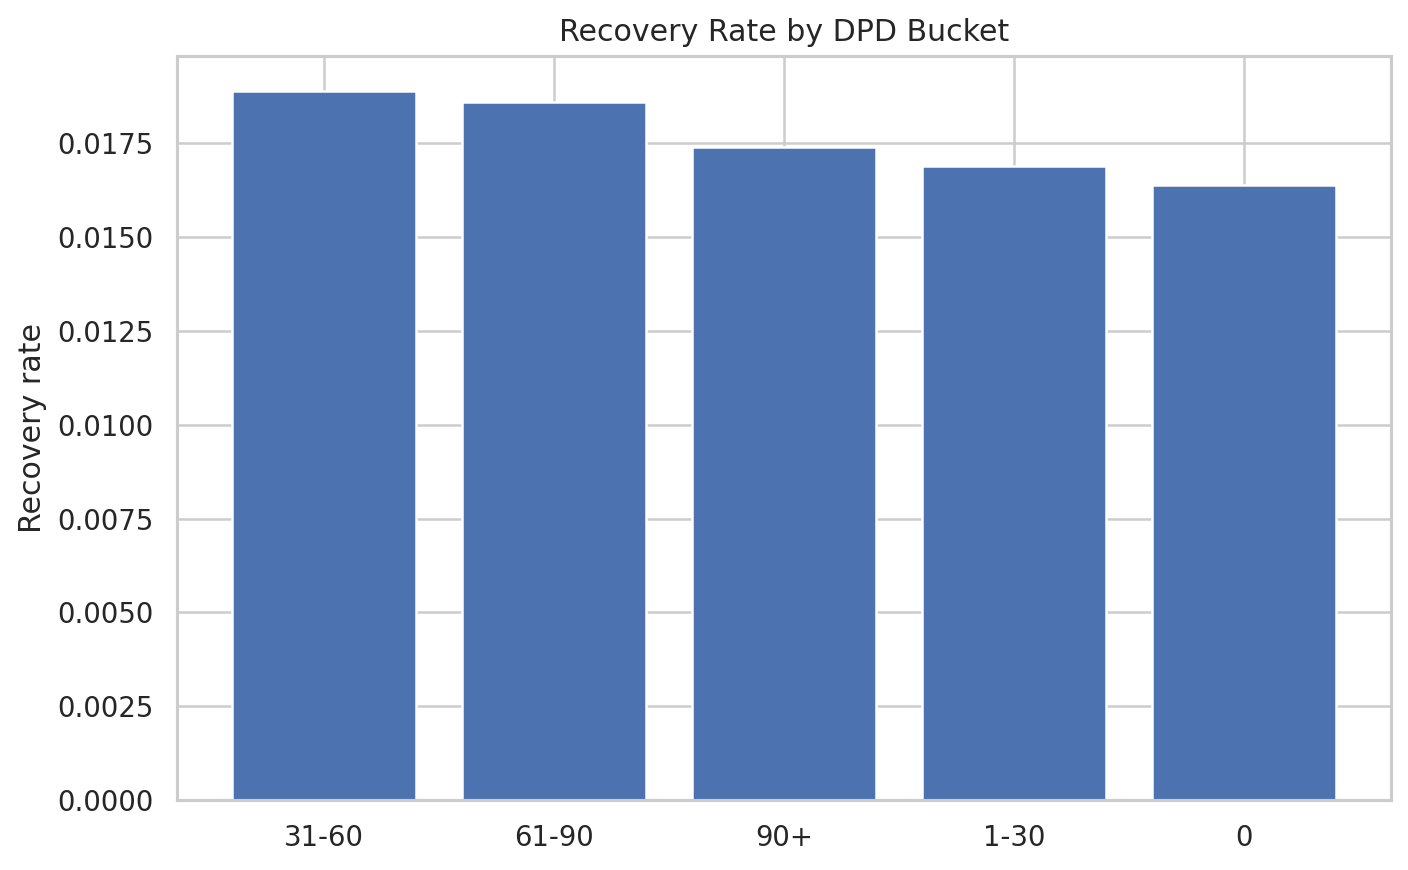

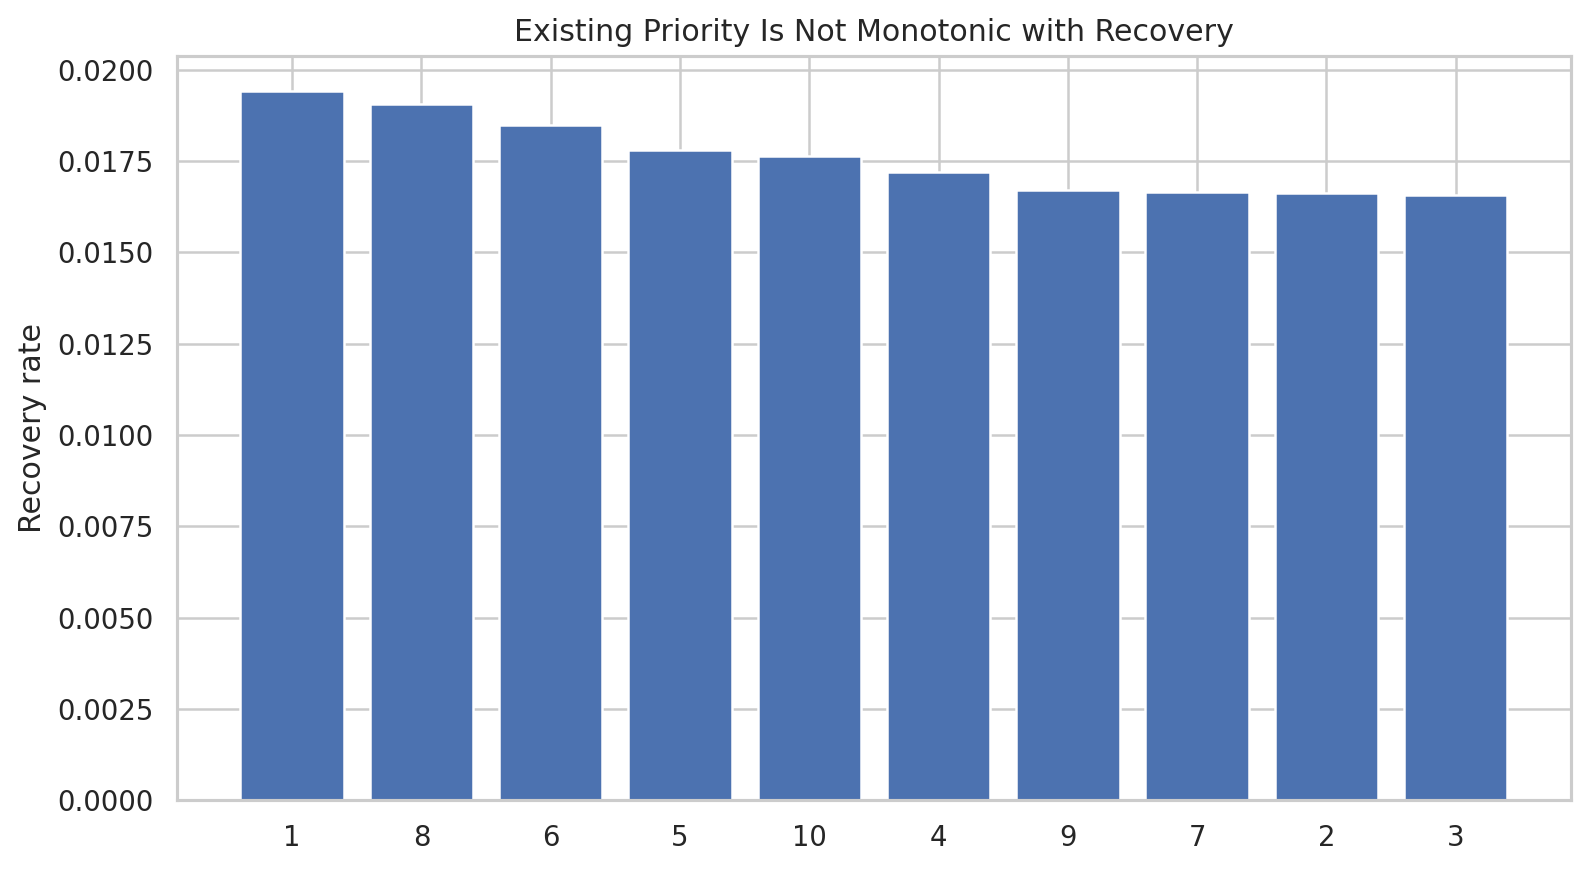

In [8]:
display(Image(filename=str(ROOT/'reports/charts/03_dpd_recovery.png'))); display(Image(filename=str(ROOT/'reports/charts/06_priority_signal.png')))

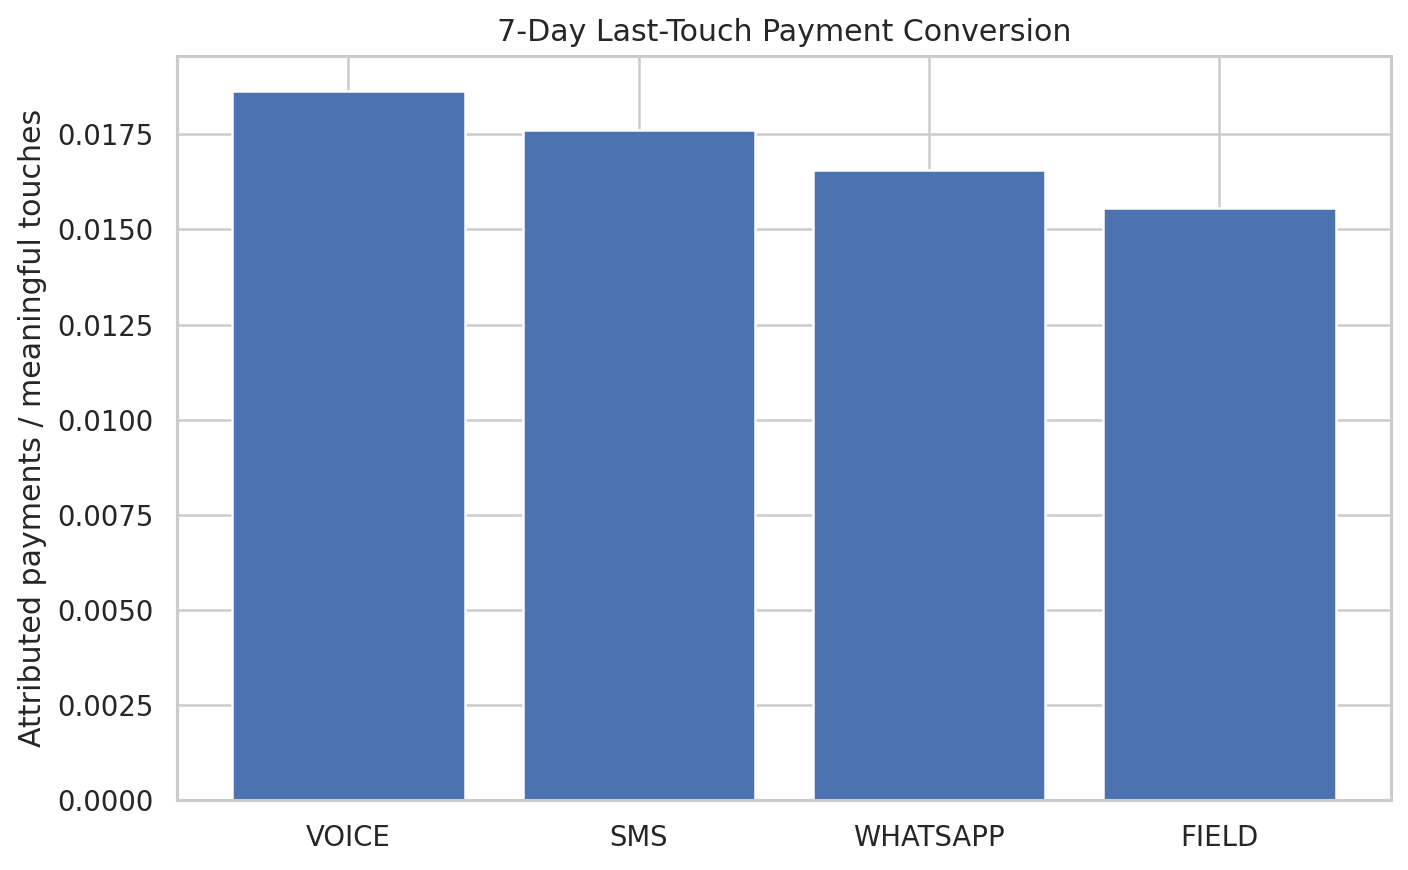

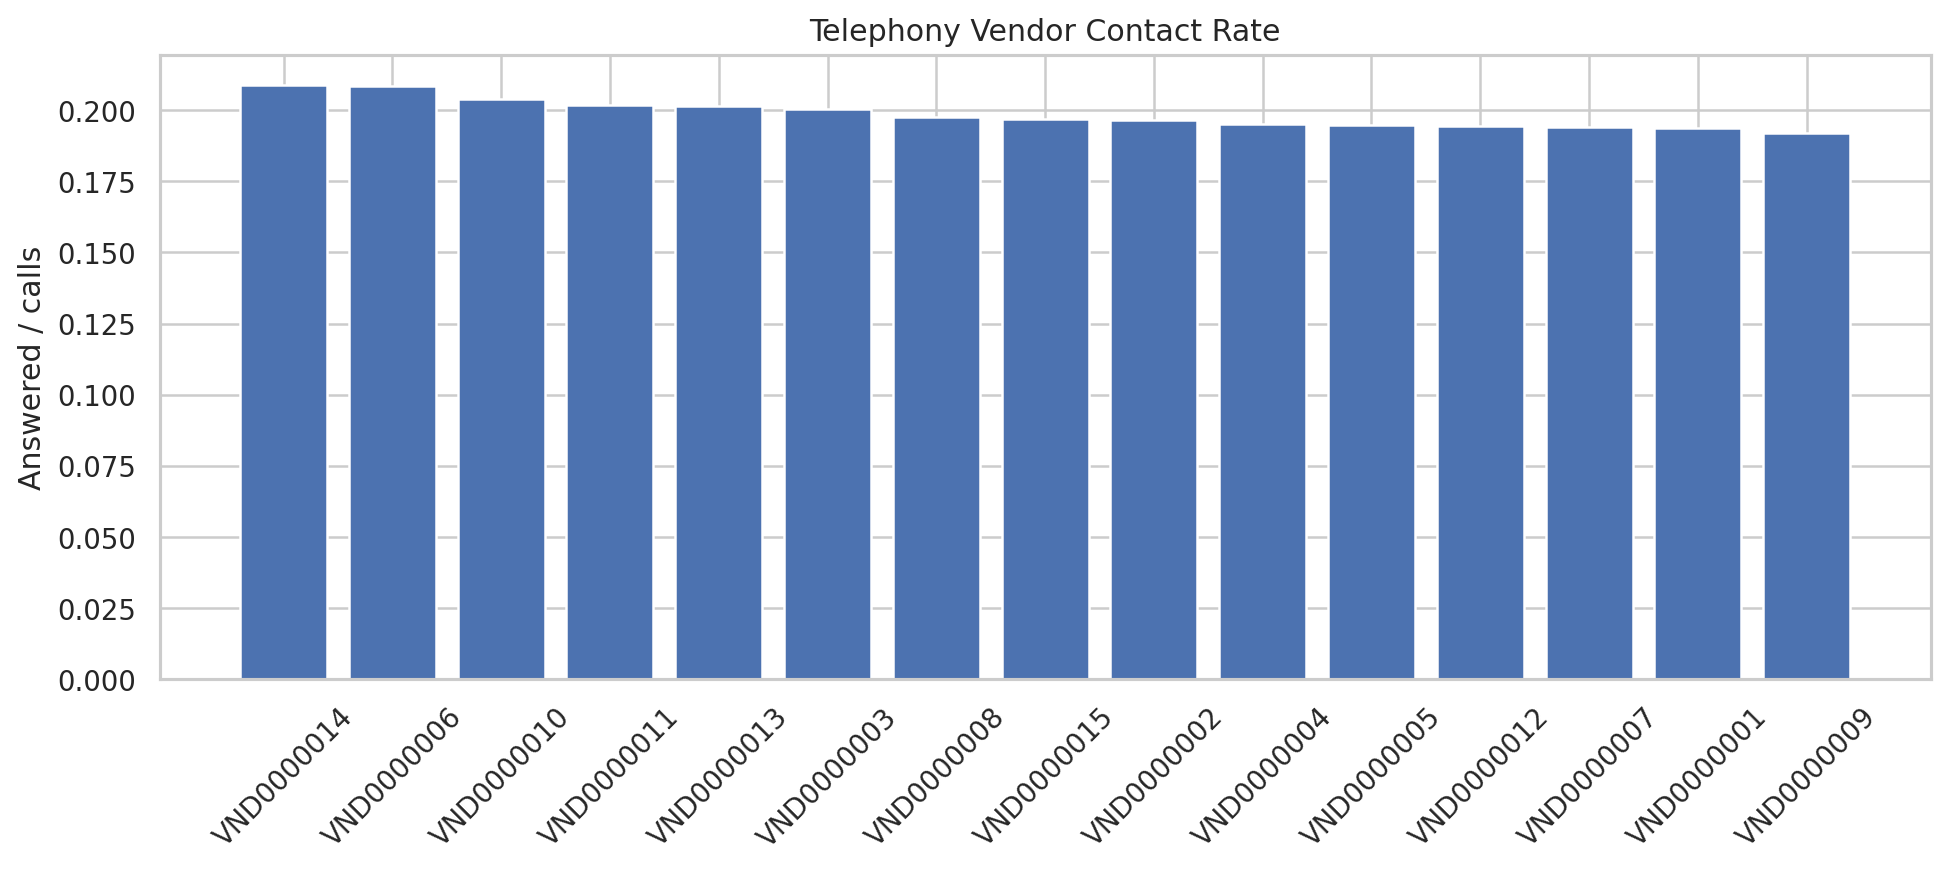

In [9]:
display(Image(filename=str(ROOT/'reports/charts/07_channel_conversion.png'))); display(Image(filename=str(ROOT/'reports/charts/08_vendor_contact_rate.png')))

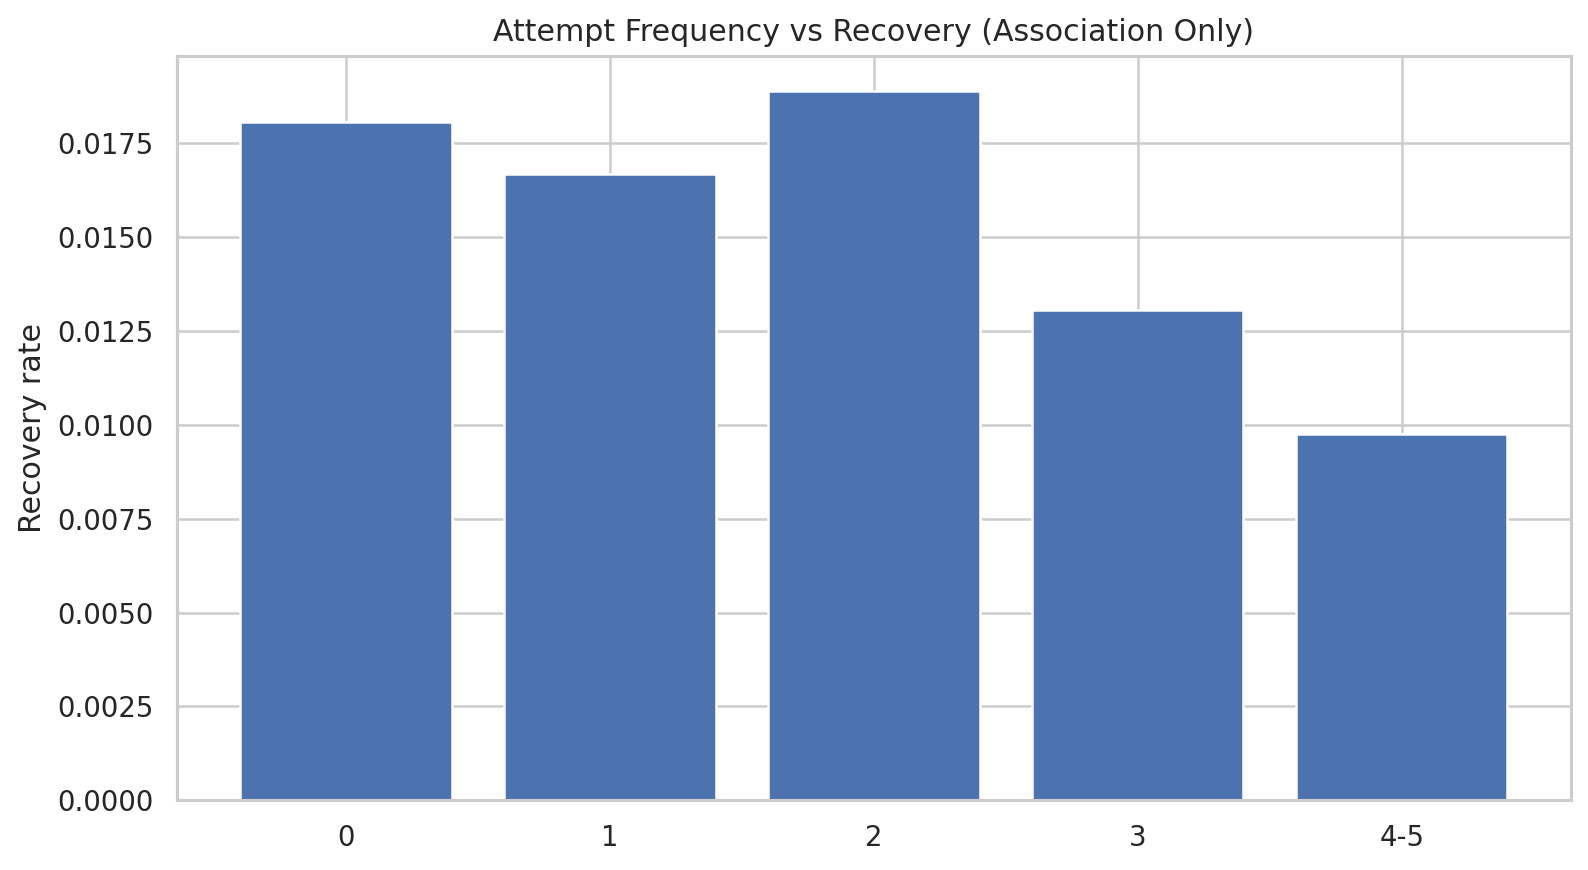

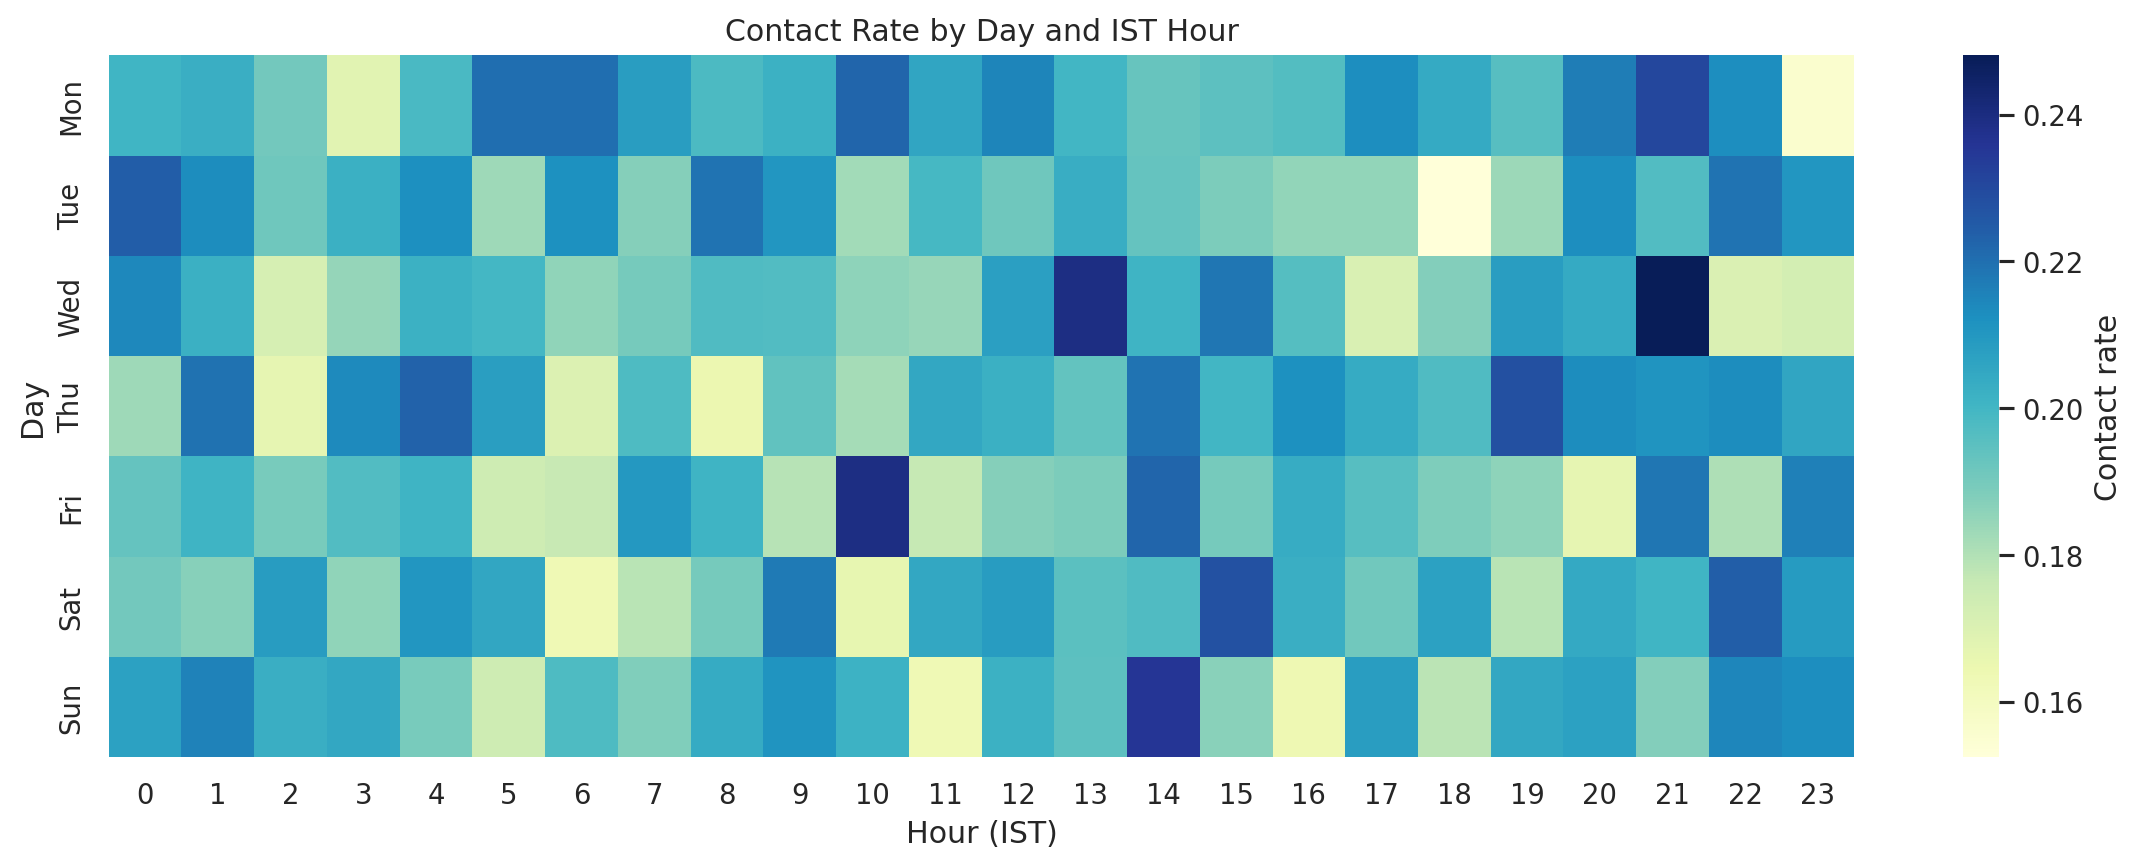

In [10]:
display(Image(filename=str(ROOT/'reports/charts/09_attempt_frequency.png'))); display(Image(filename=str(ROOT/'reports/charts/10_calling_time_heatmap.png')))

## 7. Statistical investigation
Mix adjustment uses February exposure weights across DPD bucket × risk segment × loan type. Bootstrap resampling of account-month exposure/recovery gives a wide but positive 95% interval for the Feb→Mar targeted-rate change. Selection and survivorship remain concerns because targeting is not randomized and historical account outstanding balances are not versioned.

In [11]:
print('Mix-adjusted Feb→Mar change: 26.17%')
print('Bootstrap 95% CI: [7.88%, 47.87%]')
print('Jan-Jul recovery trend p-value: 0.891')
print('Jan-Jul targeted-rate trend p-value: 0.967')

Mix-adjusted Feb→Mar change: 26.17%
Bootstrap 95% CI: [7.88%, 47.87%]
Jan-Jul recovery trend p-value: 0.891
Jan-Jul targeted-rate trend p-value: 0.967


## 8. Counterfactual design
The files do not contain a clean, documented strategy-switch flag that creates a credible treatment/control split. A causal answer should therefore **not be fabricated**. Recommended production test: randomized account-level holdout stratified by DPD/risk/client-equivalent portfolio segment; treatment receives the new targeting policy, control retains current policy. Primary outcome = 30-day recovery / opening exposure; guardrails = complaints, PTP kept, contact frequency. If retrospective estimation is mandatory, use matched Difference-in-Differences only after validating pre-trends and stable treatment assignment.

## 9. ₹10 Cr investment decision
**Recommendation: Better borrower targeting, with a stage-gated rollout rather than an unconditional ₹10 Cr deployment.** Current priority values are not monotonic with recovery, indicating ranking headroom. Telephony vendors show only a narrow contact-rate spread, field has no superior attributed conversion, and AI voice has no directly identified treatment in the data. The full ₹10 Cr requires a material incremental recovery lift; the controlled experiment should be the funding gate.

In [12]:
sc=pd.read_csv(ROOT/'data/golden/investment_scenarios.csv'); sc

,scenario,lift_pp,incremental_recovery,roi_pct,breakeven_months
0,Downside,0.10000,2.352674e+07,-76.473258,51.005786
1,Evidence-based base,0.19951,4.693819e+07,-53.061807,25.565534
2,Upside / hurdle,0.50000,1.176337e+08,17.633712,10.201157


## 10. Final conclusion
The **11% Feb→Mar arithmetic is real**, but the broader statement “operational recovery has improved” is not supported as a sustained trend. The responsible executive conclusion is: **one-month improvement, not a proven structural improvement**. Fix metric governance and identity/attribution quality, then prove targeting lift with a controlled holdout before scaling the ₹10 Cr investment.